# TP_2

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_regression, make_classification
from sklearn.model_selection import train_test_split

np.random.seed(42)

In [8]:
# Dataset 1: Linear Regression
X_reg, y_reg = make_regression(
    n_samples=500,
    n_features=5,
    n_informative=3,
    noise=20,
    random_state=42
)

cols_reg = ['area', 'rooms', 'dist_center', 'floor', 'year']
df_reg = pd.DataFrame(X_reg, columns=cols_reg)
df_reg['price'] = y_reg

# Dataset 2: Logistic Regression
X_clf, y_clf = make_classification(
    n_samples=800,
    n_features=10,
    n_informative=6,
    n_redundant=2,
    n_classes=2,
    class_sep=1.2,
    random_state=42
)

# Dataset 3: XGBoost
X_xgb, y_xgb = make_classification(
    n_samples=1000,
    n_features=12,
    n_informative=8,
    n_redundant=2,
    n_classes=3,
    n_clusters_per_class=2,
    random_state=42
)

print("Shapes:", X_reg.shape, X_clf.shape, X_xgb.shape)
print("Class distribution (clf):", np.bincount(y_clf))
print("Class distribution (xgb):", np.bincount(y_xgb))

Shapes: (500, 5) (800, 10) (1000, 12)
Class distribution (clf): [399 401]
Class distribution (xgb): [334 335 331]


----
---

# Exercice 1

Q1

In [9]:
df_reg.head()

,area,rooms,dist_center,floor,year,price
0,-0.109610,0.546284,-0.088363,0.006422,-0.436386,71.915711
1,-1.024388,-0.926930,-0.252568,-0.059525,-3.241267,-115.327086
2,-2.650970,0.106430,1.091507,-0.254977,1.503993,30.002861
3,-0.850520,-0.138456,-0.580523,-1.224298,-0.209023,-135.823205
4,-0.322680,-0.756795,-0.250833,-1.421811,1.501334,-121.408351


The first 5 rows show that all input features are numerical and centered roughly around 0.
Their values seem to be on comparable scales, with both negative and positive values.

Q2

In [10]:
df_reg['price'].describe()

count    500.000000
mean       3.491573
std      109.639282
min     -295.241963
25%      -68.567178
50%        5.244219
75%       75.231556
max      339.752493
Name: price, dtype: float64

So :

std      109.639282
min     -295.241963

Q3

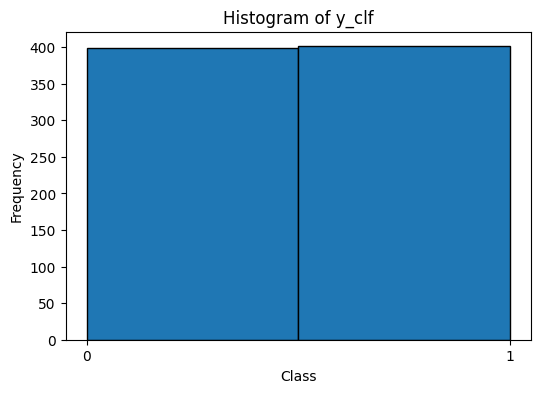

In [11]:
plt.figure(figsize=(6,4))
plt.hist(y_clf, bins=2, edgecolor='black')
plt.xticks([0, 1])
plt.xlabel("Class")
plt.ylabel("Frequency")
plt.title("Histogram of y_clf")
plt.show()

We can see it's similar but not really equal

Q4

`n_informative` is the number of features that actually contain useful information for predicting the target.

Its purpose is to control how many variables really influence the output.

Q5

"reg" will be used for linear regression because the target `y_reg` is continuous.

"clf" will be used for binary classification because `y_clf` contains two classes: 0 and 1.

"xgb" will be used for multiclass classification because `y_xgb` contains three classes.

----
---



# Exercice 2 


RMSE=20.46 MAE=16.54 R2=0.9648


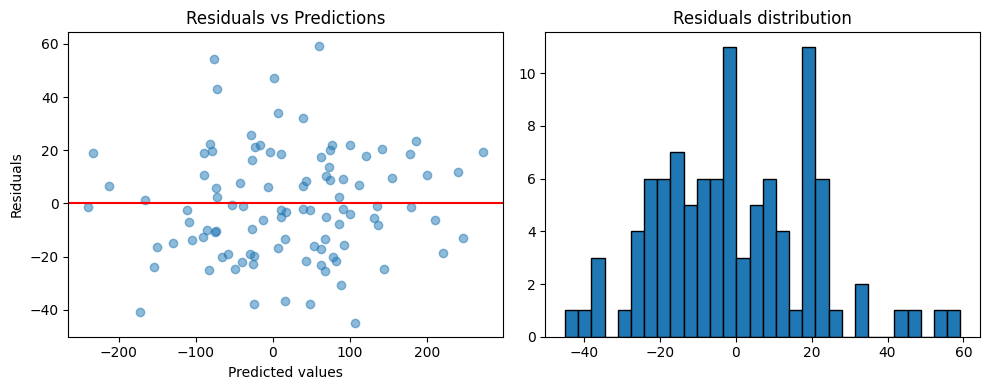

In [12]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Train/test split (80/20)
X_tr, X_te, y_tr, y_te = train_test_split(
X_reg, y_reg, test_size=0.2, random_state=42
)

# Pipeline: normalization + regression
pipe = Pipeline([
('scaler', StandardScaler()),
('model', LinearRegression())
])
pipe.fit(X_tr, y_tr)
y_pred = pipe.predict(X_te)

# Metrics
mse = mean_squared_error(y_te, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_te, y_pred)
r2 = r2_score(y_te, y_pred)
print(f'RMSE={rmse:.2f} MAE={mae:.2f} R2={r2:.4f}')

# Residuals plot
residuals = y_te - y_pred
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='red')
plt.xlabel('Predicted values'); plt.ylabel('Residuals')
plt.title('Residuals vs Predictions')
plt.subplot(1,2,2)
plt.hist(residuals, bins=30, edgecolor='black')
plt.title('Residuals distribution')
plt.tight_layout(); plt.show()

In [13]:
from sklearn.model_selection import GridSearchCV

# Ridge regularization
ridge_pipe = Pipeline([('scaler', StandardScaler()),
('model', Ridge())])

param_grid_ridge = {'model__alpha': [0.01, 0.1, 1, 10, 100]}
gs_ridge = GridSearchCV(ridge_pipe, param_grid_ridge, cv=5,
scoring='neg_mean_squared_error')
gs_ridge.fit(X_tr, y_tr)

print('Ridge best alpha:', gs_ridge.best_params_)

# Lasso regularization
lasso_pipe = Pipeline([('scaler', StandardScaler()),
('model', Lasso(max_iter=5000))])
param_grid_lasso = {'model__alpha': [0.001, 0.01, 0.1, 1, 10]}
gs_lasso = GridSearchCV(lasso_pipe, param_grid_lasso, cv=5,
scoring='neg_mean_squared_error')
gs_lasso.fit(X_tr, y_tr)

print('Lasso best alpha:', gs_lasso.best_params_)

# Lasso coefficients (feature selection)
lasso_best = gs_lasso.best_estimator_.named_steps['model']

print('Coefs Lasso:', lasso_best.coef_)

Ridge best alpha: {'model__alpha': 0.1}
Lasso best alpha: {'model__alpha': 0.1}
Coefs Lasso: [-0.59425824 77.75398169  0.         70.91493702 11.28468352]


Q2.1

So RMSE=20.46 MAE=16.54 R2=0.9648

Q2.2

Yes, the residuals are approximately centered around 0.

This indicates that the model does not show systematic bias.

The random dispersion of residuals around zero suggests that
the linear model is appropriate for this dataset and fits well.

Q2.3

MSE (Mean Squared Error) is the average of squared residuals.

RMSE (Root Mean Squared Error) is the square root of MSE.

RMSE is easier to interpret because it is expressed in the same units as the target variable,
while MSE is in squared units and less intuitive.

So maybe RMSE is more interpretable.

Q2.4

Regularization is a technique that adds a penalty to large coefficients in order to reduce overfitting and improve model generalization.

Q2.5

Ridge adds a squared penalty on coefficients and shrinks them toward zero but never exactly to zero.

Lasso adds an absolute penalty and can set some coefficients exactly to zero,
which makes it useful for feature selection.

Q2.6

In [19]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.model_selection import GridSearchCV

import matplotlib.pyplot as plt

# Ridge alpha = 0.01
ridge_small = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=0.01))
])

ridge_small.fit(X_tr, y_tr)
coef_small = ridge_small.named_steps['model'].coef_

# Ridge alpha = 100
ridge_large = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=100))
])

ridge_large.fit(X_tr, y_tr)
coef_large = ridge_large.named_steps['model'].coef_

print("\nQ2.6 — Ridge coefficients comparison")
print("Alpha = 0.01:", coef_small)
print("Alpha = 100 :", coef_large)

# Ridge regularization (GridSearch)
ridge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge())
])

param_grid_ridge = {'model__alpha': [0.01, 0.1, 1, 10, 100]}

gs_ridge = GridSearchCV(
    ridge_pipe,
    param_grid_ridge,
    cv=5,
    scoring='neg_mean_squared_error'
)

gs_ridge.fit(X_tr, y_tr)

print('\nRidge best alpha:', gs_ridge.best_params_)

# Lasso regularization
lasso_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(max_iter=5000))
])

param_grid_lasso = {'model__alpha': [0.001, 0.01, 0.1, 1, 10]}

gs_lasso = GridSearchCV(
    lasso_pipe,
    param_grid_lasso,
    cv=5,
    scoring='neg_mean_squared_error'
)

gs_lasso.fit(X_tr, y_tr)




Q2.6 — Ridge coefficients comparison
Alpha = 0.01: [-6.90118854e-01  7.78447124e+01  2.32673591e-02  7.10061153e+01
  1.13738024e+01]
Alpha = 100 : [-0.85606244 62.56768019  0.17693443 57.01015735 10.2122053 ]

Ridge best alpha: {'model__alpha': 0.1}


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=5000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': [0.001, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 :

As alpha increases from 0.01 to 100, Ridge shrinks the coefficients toward zero.

With alpha=0.01, the coefficients remain close to the ordinary least squares solution.
With alpha=100, the coefficients are noticeably smaller in magnitude, showing stronger regularization.

However, none of the coefficients become exactly zero, which is consistent with Ridge regularization.


Q2.7

In [20]:
print('Lasso best alpha:', gs_lasso.best_params_)

# Lasso coefficients (feature selection)
lasso_best = gs_lasso.best_estimator_.named_steps['model']

print('Coefs Lasso:', lasso_best.coef_)

Lasso best alpha: {'model__alpha': 0.1}
Coefs Lasso: [-0.59425824 77.75398169  0.         70.91493702 11.28468352]


`Lasso best alpha: {'model__alpha': 0.1}
Coefs Lasso: [-0.59425824 77.75398169  0.         70.91493702 11.28468352]`



One coefficient is exactly equal to zero.

This means that Lasso automatically removed one feature from the model,
indicating that this variable does not contribute significantly to predicting the target.

This illustrates the feature selection property of Lasso regularization.


Q2.8

The best alpha found by GridSearchCV is 0.1 for both Ridge and Lasso.

The performances are very similar to plain linear regression because the dataset is already well-specified and mostly linear.
Regularization does not significantly improve performance in this case.

Q2.9

Lasso is preferred when we want feature selection and a simpler, more interpretable model.

For example, in high-dimensional datasets such as gene expression data or text data,
many features may be irrelevant. Lasso can automatically remove these variables by
setting their coefficients to zero.

# Exercice 3



              precision    recall  f1-score   support

         Ham       0.81      0.90      0.85        80
        Spam       0.89      0.79      0.83        80

    accuracy                           0.84       160
   macro avg       0.85      0.84      0.84       160
weighted avg       0.85      0.84      0.84       160



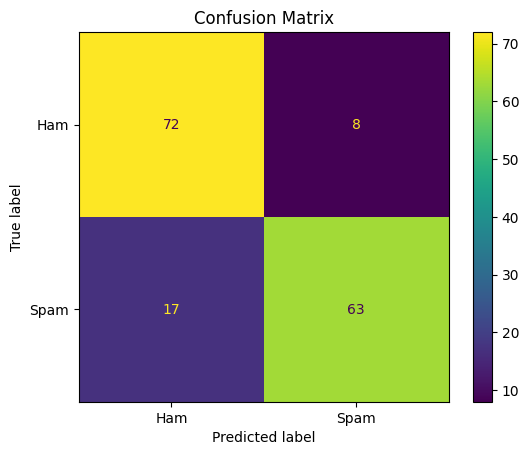

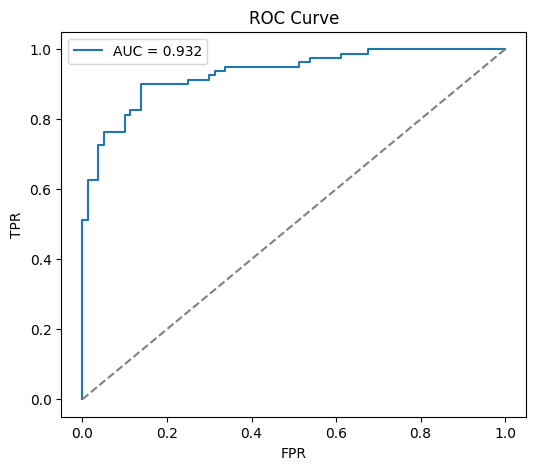

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
roc_auc_score, roc_curve, ConfusionMatrixDisplay)
X_tr2, X_te2, y_tr2, y_te2 = train_test_split(
X_clf, y_clf, test_size=0.2, stratify=y_clf, random_state=42
)

# Logistic pipeline with L2 regularization (default)
log_pipe = Pipeline([
('scaler', StandardScaler()),
('clf', LogisticRegression(max_iter=1000, random_state=42))
])

log_pipe.fit(X_tr2, y_tr2)

# Predictions and probabilities
y_pred2 = log_pipe.predict(X_te2)
y_proba = log_pipe.predict_proba(X_te2)[:, 1]

# Classification report
print(classification_report(y_te2, y_pred2,
target_names=['Ham', 'Spam']))

# Confusion matrix
cm = confusion_matrix(y_te2, y_pred2)
ConfusionMatrixDisplay(cm, display_labels=['Ham','Spam']).plot()
plt.title('Confusion Matrix'); plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(y_te2, y_proba)
auc = roc_auc_score(y_te2, y_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('ROC Curve'); plt.legend(); plt.show()

Optimal threshold (F1): 0.40


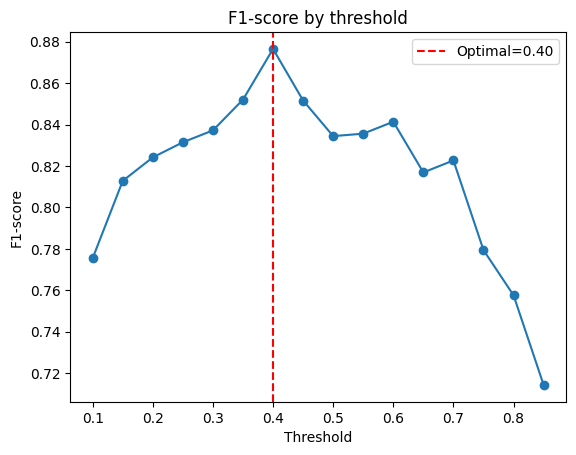

In [24]:
# Default threshold is 0.5 – we can optimize it
thresholds = np.arange(0.1, 0.9, 0.05)
f1_scores = []

from sklearn.metrics import f1_score

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    f1_scores.append(f1_score(y_te2, y_pred_t))

best_t = thresholds[np.argmax(f1_scores)]

print(f'Optimal threshold (F1): {best_t:.2f}')
plt.plot(thresholds, f1_scores, marker='o')
plt.axvline(best_t, color='red', linestyle='--', label=f'Optimal={best_t:.2f}')
plt.xlabel('Threshold'); plt.ylabel('F1-score')
plt.title('F1-score by threshold'); plt.legend(); plt.show()

Q3.1

Accuracy = 0.84  
F1-score (Spam) = 0.83  

The model is satisfactory because it achieves good accuracy and F1-score,
indicating balanced performance between precision and recall for spam detection.

Q3.2

63 spams were correctly detected (true positives).
8 legitimate emails were wrongly classified as spam (false positives).

Q3.3

AUC = 0.932

AUC-ROC measures how well the model separates the two classes across all thresholds.

A value close to 1 is very good and indicates strong discriminative ability.
Here, an AUC of 0.932 shows excellent classification performance.

Q3.4

Accuracy slightly decreases with C=0.01.

Strong regularization shrinks the coefficients too much,
which leads to underfitting and slightly worse performance.

Q3.5

The decision threshold is the probability cutoff used to assign a class (0.5 by default).

If we lower it to 0.3, more emails will be classified as spam.
This increases recall but may reduce precision.

Q3.6

The optimal threshold is 0.40 because it maximizes the F1-score.

It provides the best balance between precision and recall,
making it more appropriate than the default threshold of 0.5.

# Exercice 4

In [29]:
import xgboost as xgb
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder
X_tr3, X_te3, y_tr3, y_te3 = train_test_split(
X_xgb, y_xgb, test_size=0.2, stratify=y_xgb, random_state=42
)
# XGBoost model (scikit-learn API)
xgb_clf = xgb.XGBClassifier(
n_estimators=200,
max_depth=4,
learning_rate=0.1,
subsample=0.8,
colsample_bytree=0.8,
use_label_encoder=False,
eval_metric='mlogloss',
random_state=42
)
xgb_clf.fit(
X_tr3, y_tr3,
eval_set=[(X_te3, y_te3)],
verbose=False
)
y_pred3 = xgb_clf.predict(X_te3)
print('Accuracy:', accuracy_score(y_te3, y_pred3))
print(classification_report(y_te3, y_pred3,
target_names=['Species A','Species B','Species C']))

C:\Users\corio\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\xgboost\training.py:200: UserWarning: [16:51:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.815
              precision    recall  f1-score   support

   Species A       0.87      0.79      0.83        67
   Species B       0.77      0.84      0.80        67
   Species C       0.82      0.82      0.82        66

    accuracy                           0.81       200
   macro avg       0.82      0.82      0.82       200
weighted avg       0.82      0.81      0.82       200



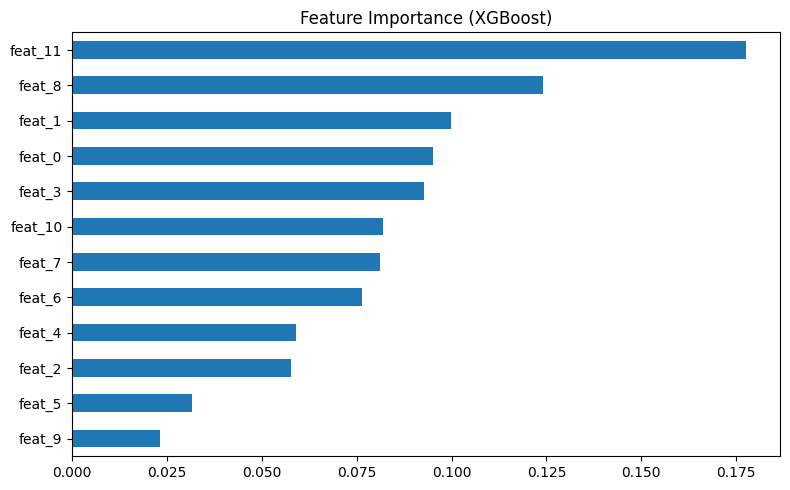

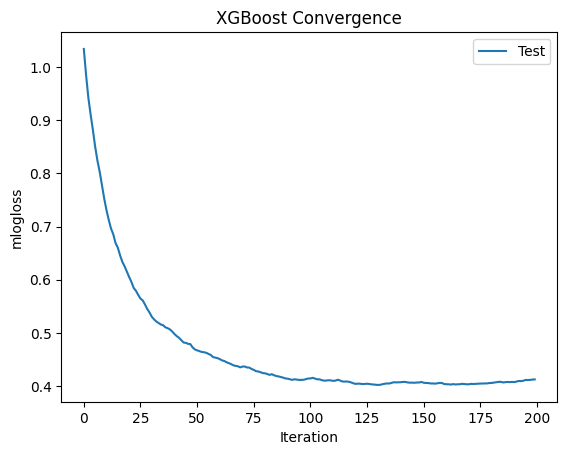

Best parameters: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
Best CV score: 0.8775000000000001


In [30]:
#Feature importance
feat_imp = pd.Series(xgb_clf.feature_importances_,
index=[f'feat_{i}' for i in range(X_xgb.shape[1])])
feat_imp.sort_values().plot(kind='barh', figsize=(8,5),
title='Feature Importance (XGBoost)')
plt.tight_layout(); plt.show()

#  Learning curve (evals_result) 
results = xgb_clf.evals_result()
plt.plot(results['validation_0']['mlogloss'], label='Test')
plt.xlabel('Iteration'); plt.ylabel('mlogloss')
plt.title('XGBoost Convergence'); plt.legend(); plt.show()

#  Hyperparameter tuning with RandomizedSearchCV 
from sklearn.model_selection import RandomizedSearchCV
param_dist = {
'n_estimators': [100, 200, 300],
'max_depth': [3, 4, 5, 6],
'learning_rate': [0.01, 0.05, 0.1, 0.2],
'subsample': [0.6, 0.8, 1.0],
'colsample_bytree': [0.6, 0.8, 1.0],
}

rs = RandomizedSearchCV(
xgb.XGBClassifier(eval_metric='mlogloss', random_state=42),
param_dist, n_iter=20, cv=5,
scoring='accuracy', random_state=42, n_jobs=-1
)

rs.fit(X_tr3, y_tr3)
print('Best parameters:', rs.best_params_)
print('Best CV score:', rs.best_score_)

Q4.1

The accuracy with XGBoost is 0.815.

It is slightly lower than logistic regression (0.84), meaning logistic regression performs better on this dataset.

Q4.2

Boosting is an ensemble method that builds models sequentially,
where each new model focuses on correcting the errors made by the previous ones.

Q4.3

The loss stabilizes around iteration 120.

After this point, improvements become minimal,
indicating the model has mostly converged.

Q4.4

1.feat_11

2.feat_8

3.feat_1

Q4.5


In [31]:
import xgboost as xgb
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder
X_tr3, X_te3, y_tr3, y_te3 = train_test_split(
X_xgb, y_xgb, test_size=0.2, stratify=y_xgb, random_state=42
)
# XGBoost model (scikit-learn API)
xgb_clf = xgb.XGBClassifier(
n_estimators=200,
max_depth=4,
learning_rate=0.5,
subsample=0.8,
colsample_bytree=0.8,
use_label_encoder=False,
eval_metric='mlogloss',
random_state=42
)
xgb_clf.fit(
X_tr3, y_tr3,
eval_set=[(X_te3, y_te3)],
verbose=False
)
y_pred3 = xgb_clf.predict(X_te3)
print('Accuracy:', accuracy_score(y_te3, y_pred3))
print(classification_report(y_te3, y_pred3,
target_names=['Species A','Species B','Species C']))

C:\Users\corio\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\xgboost\training.py:200: UserWarning: [16:52:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.83
              precision    recall  f1-score   support

   Species A       0.87      0.81      0.84        67
   Species B       0.79      0.85      0.82        67
   Species C       0.83      0.83      0.83        66

    accuracy                           0.83       200
   macro avg       0.83      0.83      0.83       200
weighted avg       0.83      0.83      0.83       200



With learning_rate=0.5, the accuracy becomes 0.83.

This is slightly higher than before (0.815), but generally a higher learning rate makes updates more aggressive
and can reduce stability and generalization.

Even if performance slightly improves here, smaller learning rates are usually preferred
because they lead to more stable convergence.

Q4.6

`Best parameters: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
Best CV score: 0.8775000000000001`

Yes, the score improves compared with the initial XGBoost test accuracy (0.815),
which shows that hyperparameter tuning helps the model perform better.

# Exercice 5



               Accuracy     F1  AUC-ROC
Logistic Reg.    0.8438 0.8344   0.9320
Random Forest    0.9437 0.9427   0.9703
XGBoost          0.9437 0.9434   0.9756


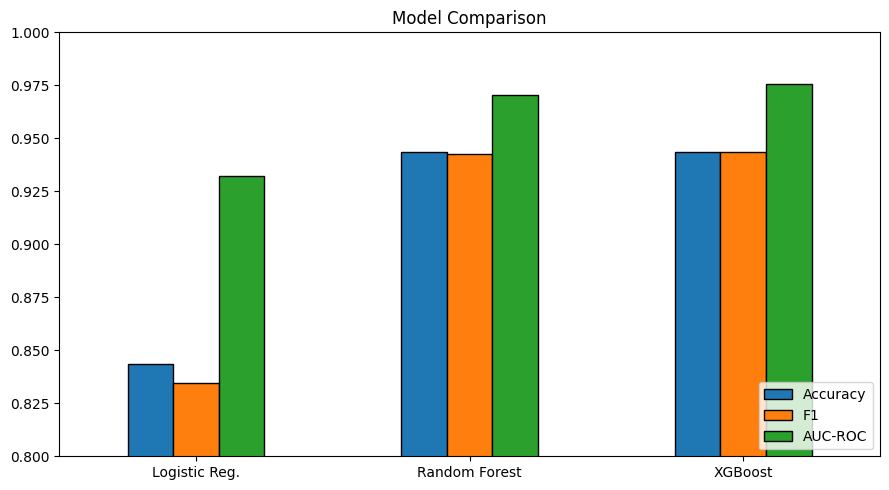

In [32]:
# Compare on the same binary classification dataset
# (X_clf, y_clf) with Logistic Regression vs XGBoost vs Random Forest


from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import xgboost as xgb

# Models
models = {
    'Logistic Reg.': Pipeline([
        ('sc', StandardScaler()),
        ('m', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    
    'XGBoost': xgb.XGBClassifier(
        n_estimators=200,
        max_depth=4,
        eval_metric='logloss',
        random_state=42
    )
}

# Training + Evaluation loop
results_comp = {}

for name, model in models.items():
    
    # Fit
    model.fit(X_tr2, y_tr2)
    
    # Predictions
    yp = model.predict(X_te2)
    yprb = model.predict_proba(X_te2)[:, 1]
    
    # Metrics
    results_comp[name] = {
        'Accuracy': accuracy_score(y_te2, yp),
        'F1': f1_score(y_te2, yp),
        'AUC-ROC': roc_auc_score(y_te2, yprb),
    }

# Results table
df_results = pd.DataFrame(results_comp).T
print(df_results.to_string(float_format='{:.4f}'.format))

# Visualization
df_results.plot(kind='bar', figsize=(9,5), edgecolor='black')

plt.title('Model Comparison')
plt.xticks(rotation=0)
plt.ylim(0.8, 1.0)
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

Q5.1


| Model               | Accuracy | F1-Score | AUC-ROC | Fit time | Interpretable? |
|---------------------|----------|----------|---------|----------|----------------|
| Logistic Regression | 0.8438   | 0.8344   | 0.9320  | Fast     | Yes            |
| Random Forest       | 0.9437   | 0.9427   | 0.9703  | Medium   | Partial        |
| XGBoost             | 0.9437   | 0.9434   | 0.9756  | Slow     | Partial        |

Q5.2

XGBoost achieved the best overall performance, especially in AUC-ROC.

Yes, this was expected because boosting methods often outperform simpler models
by capturing more complex patterns in the data.

Q5.3

Logistic Regression is the easiest model to interpret.

One concrete advantage is that each coefficient directly shows how a feature
influences the prediction, making it easier to explain decisions.

Q5.4

I would choose XGBoost for real-world use because it offers the best predictive performance
while still being relatively efficient.

In many applications, predictive accuracy is more important than full interpretability.